<a href="https://colab.research.google.com/github/caioh639/AirbnbRJ/blob/main/ProjectAirbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
listings = pd.read_csv('/content/listings-2.csv')

# Validando DF Principal


In [3]:
listings.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN


In [4]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [5]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            43068 non-null  int64  
 1   listing_url                                   43068 non-null  object 
 2   scrape_id                                     43068 non-null  int64  
 3   last_scraped                                  43068 non-null  object 
 4   source                                        43068 non-null  object 
 5   name                                          43068 non-null  object 
 6   description                                   42017 non-null  object 
 7   neighborhood_overview                         16330 non-null  object 
 8   picture_url                                   43068 non-null  object 
 9   host_id                                       43068 non-null 

In [6]:
listings.shape

(43068, 79)

In [7]:
listings = pd.read_csv('/content/listings-2.csv')
listings[['price', 'accommodates', 'bedrooms', 'review_scores_rating','number_of_reviews']].head()

,price,accommodates,bedrooms,review_scores_rating,number_of_reviews
0,$580.00,4,2.0,4.93,86
1,"$1,900.00",2,1.0,NaN,0
2,$700.00,4,1.0,NaN,0
3,NaN,2,NaN,5.00,3
4,$500.00,4,1.0,4.91,11


In [8]:
info = listings[['price', 'accommodates', 'bedrooms', 'review_scores_rating','number_of_reviews']]

In [9]:
listings[['price', 'accommodates', 'bedrooms', 'review_scores_rating','number_of_reviews']].isnull().sum()

,0
price,4398
accommodates,0
bedrooms,972
review_scores_rating,9186
number_of_reviews,0


In [10]:
info.duplicated().sum() #descobrindo a quantidade de duplicados

np.int64(7386)

In [11]:
listings.duplicated().sum()

np.int64(0)

In [12]:
listings[['neighborhood_overview','neighbourhood_cleansed', 'neighbourhood_group_cleansed']].tail(10)

,neighborhood_overview,neighbourhood_cleansed,neighbourhood_group_cleansed
43058,NaN,Maracanã,NaN
43059,NaN,Leme,NaN
43060,"The Flamengo neighborhood has shops, restauran...",Laranjeiras,NaN
43061,NaN,Centro,NaN
43062,NaN,Copacabana,NaN
43063,Ipanema is the heart of Rio culture. Discover ...,Ipanema,NaN
43064,NaN,Botafogo,NaN
43065,NaN,Copacabana,NaN
43066,NaN,Botafogo,NaN
43067,NaN,Laranjeiras,NaN


# Iniciando tratativa do primeiro: df_listings

In [13]:
df_listings = listings[[ #definindo as infomacoes do dataframe
    'id',
    'host_id',
    'host_name',
    'name',
    'neighbourhood_cleansed',
    'room_type',
    'property_type',
    'price',
    'accommodates',
    'bedrooms',
    'beds'
]]

In [14]:
df_listings.info() #entendo as colunas e quantidade de vazios (ponto de atencao no preco)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   host_id                 43068 non-null  int64  
 2   host_name               43057 non-null  object 
 3   name                    43068 non-null  object 
 4   neighbourhood_cleansed  43068 non-null  object 
 5   room_type               43068 non-null  object 
 6   property_type           43068 non-null  object 
 7   price                   38670 non-null  object 
 8   accommodates            43068 non-null  int64  
 9   bedrooms                42096 non-null  float64
 10  beds                    38660 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 3.6+ MB


In [15]:
df_listings.isnull().sum()

,0
id,0
host_id,0
host_name,11
name,0
neighbourhood_cleansed,0
room_type,0
property_type,0
price,4398
accommodates,0
bedrooms,972


In [16]:
df_listings = df_listings.dropna(subset=['price']) #apagando todas as linhas onde price esteja vazio e salvando um novo df

In [17]:
df_listings.isnull().sum()

,0
id,0
host_id,0
host_name,11
name,0
neighbourhood_cleansed,0
room_type,0
property_type,0
price,0
accommodates,0
bedrooms,74


In [18]:
df_listings['price'].describe() #ja fica claro que o price nao está como numero


,price
count,38670
unique,2600
top,$200.00
freq,403


In [19]:
df_listings['property_type'].value_counts().head(30) #contando a quantidade de tipo de propridades

,count
property_type,
Entire rental unit,25710
Private room in rental unit,4277
Entire home,1933
Entire condo,1622
Private room in home,1337
Entire loft,766
Entire serviced apartment,649
Private room in bed and breakfast,380
Private room in condo,331


In [20]:
df_listings['neighbourhood_cleansed'].unique() #analisando os bairros dos listings


array(['Leblon', 'Copacabana', 'Pavuna', 'Barra da Tijuca', 'Leme',
       'Botafogo', 'Ipanema', 'Marechal Hermes', 'Tijuca', 'Camorim',
       'Vidigal', 'Santíssimo', 'Catete', 'Centro', 'Jacarepaguá',
       'Santa Teresa', 'Santa Cruz', 'São Conrado', 'Campo Grande',
       'Freguesia (Jacarepaguá)', 'Recreio dos Bandeirantes', 'Flamengo',
       'Rio Comprido', 'Barra de Guaratiba', 'Jardim Botânico',
       'Engenheiro Leal', 'Vigário Geral', 'Estácio', 'Engenho de Dentro',
       'Urca', 'Grajaú', 'Itanhangá', 'Vargem Pequena', 'Vargem Grande',
       'Irajá', 'Laranjeiras', 'Vila Isabel', 'Gávea', 'Cacuia',
       'São Cristóvão', 'Anil', 'Jardim Sulacap', 'Del Castilho',
       'Bento Ribeiro', 'Joá', 'Méier', 'Catumbi', 'Penha Circular',
       'Taquara', 'Maracanã', 'Rocha Miranda', 'Humaitá', 'Santo Cristo',
       'Vaz Lobo', 'Paquetá', 'Praça da Bandeira', 'Brás de Pina',
       'Lagoa', 'Inhaúma', 'Curicica', 'Praça Seca', 'Vila da Penha',
       'Glória', 'Alto da Boa 

In [21]:
df_listings['bedrooms'] = df_listings['bedrooms'].fillna(1)

In [22]:
df_listings.isnull().sum() #considerando que todos que nao tem quartos é pq sao estudios ou kitnets

,0
id,0
host_id,0
host_name,11
name,0
neighbourhood_cleansed,0
room_type,0
property_type,0
price,0
accommodates,0
bedrooms,0


In [23]:
df_listings['price'] = ( #transformando price DE OBJECT PARA FLOAT IMPORTANTE
    df_listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [24]:
df_listings['price'].describe() #analise do comportamento dos preços dps imóveis

,price
count,38670.000000
mean,717.535325
std,4388.082802
min,30.000000
25%,202.000000
50%,317.000000
75%,565.000000
max,500000.000000


In [25]:
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38670 entries, 0 to 43067
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      38670 non-null  int64  
 1   host_id                 38670 non-null  int64  
 2   host_name               38659 non-null  object 
 3   name                    38670 non-null  object 
 4   neighbourhood_cleansed  38670 non-null  object 
 5   room_type               38670 non-null  object 
 6   property_type           38670 non-null  object 
 7   price                   38670 non-null  float64
 8   accommodates            38670 non-null  int64  
 9   bedrooms                38670 non-null  float64
 10  beds                    38656 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 3.5+ MB



> o resultado acima é importantissimo




# Compreendendo os outliers de price abaixo

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


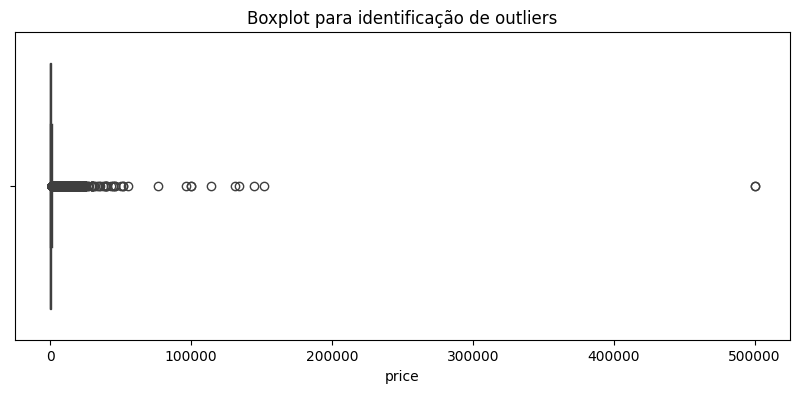

In [27]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_listings['price'])
plt.title('Boxplot para identificação de outliers')
plt.show()

In [28]:
Q1 = df_listings['price'].quantile(0.25)
Q3 = df_listings['price'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_listings[df_listings['price'] > limite_superior]

outliers.shape

(3792, 11)

o código acima calcula os valores do 1 quartil e 3 quatil e logo em seguida defini o limite superior. qualquer valor acima do limite superior é considerado um outlier

logo em seguida coloca-se todos os registros que sao outliers no dataframe `outliers`

***como nota-se existem 3792 resultados. calculando 3792/38760 = 10%, um resultado relevante que nao deve ser descartado.***

In [29]:
df_listings.sort_values('price', ascending=False).head(5) #os 10 valores de preço mais alto mais altos


,id,host_id,host_name,name,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds
7624,30033272,122258300,Ricardo,Apartamento em Rio de Janeiro,Estácio,Entire home/apt,Entire rental unit,500000.0,4,2.0,2.0
15026,695828287387937123,238544772,Cesar,Pede Desconto Copacabana Top Piso em Mármore,Copacabana,Entire home/apt,Entire rental unit,500000.0,4,1.0,1.0
16440,768987862539988284,229244053,Marleide Dos Santos,promoção apartamento lugar seguro próximo a Barra,Jacarepaguá,Entire home/apt,Entire rental unit,151710.0,2,1.0,1.0
21203,1020594041193205143,545665571,Ryan Rafael,Quarto em Apartamento vila do chaves,Itanhangá,Private room,Private room in rental unit,144800.0,3,1.0,2.0
13282,557903977376721724,22805631,Latin Exclusive,Rio011 - Luxury oceanfront penthouse in Copaca...,Copacabana,Entire home/apt,Entire rental unit,134358.0,10,5.0,5.0


In [30]:
df_listings['price_segment'] = pd.cut(
    df_listings['price'],
    bins=[0, 200, 500, 1000, 5000, 500000],
    labels=['Econômico', 'Padrão', 'Intermediário', 'Alto padrão', 'Luxo'] #dividindo a amostra de preços em categorias
)

In [31]:
df_listings['price_segment'].value_counts()

,count
price_segment,
Padrão,17940
Econômico,9565
Intermediário,6854
Alto padrão,3738
Luxo,573


# Fim da investigacao de preços, outliers, faixa de valor e do df_listings


In [32]:
df_listings.head(10)

,id,host_id,host_name,name,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,price_segment
0,821198084644106078,84350716,Katrina,Bright and Peaceful Leblon Loft,Leblon,Entire home/apt,Entire condo,580.0,4,2.0,3.0,Intermediário
1,821198370698658112,4347269,Patrick,Copacabana 100% reformado.,Copacabana,Entire home/apt,Entire rental unit,1900.0,2,1.0,1.0,Alto padrão
2,821200521820144734,499903412,Vanessa,hambiente familia,Pavuna,Entire home/apt,Entire rental unit,700.0,4,1.0,1.0,Intermediário
4,821223043903573522,25961210,Katia,Incrível apartamento frente mar,Barra da Tijuca,Entire home/apt,Entire rental unit,500.0,4,1.0,1.0,Padrão
5,821227099948297881,392769753,Amanda,Apt N S de Copacabana reformado!,Copacabana,Entire home/apt,Entire rental unit,461.0,6,2.0,6.0,Padrão
7,821242614763878451,46944465,Ana Lucia,Cozy space at Leme Beach,Leme,Entire home/apt,Entire rental unit,281.0,2,1.0,2.0,Padrão
8,821254575358803002,15991909,Yona,Quarto para duas pessoas,Copacabana,Private room,Private room in rental unit,950.0,2,1.0,0.0,Intermediário
9,821314145791532025,91654021,Daniel,Quarto Master no Blue Hill,Botafogo,Private room,Private room in home,450.0,4,1.0,2.0,Padrão
10,821529031538759784,8317871,Grace,"Apto em Copa para 6 pessoas, a 1 minuto da praia!",Copacabana,Entire home/apt,Entire rental unit,1000.0,6,3.0,4.0,Intermediário
11,821552389384274282,2911856,Joao,Cobertura linda e silenciosa,Copacabana,Entire home/apt,Entire rental unit,980.0,3,2.0,2.0,Intermediário


# Criando o dataframe de coordenadas geográficas

In [33]:
df_geo = listings[['id','latitude','longitude']]

In [34]:
df_geo.isnull().sum()

,0
id,0
latitude,0
longitude,0


In [35]:
df_listings = df_listings.merge( #adicionando latitude e longitude no df_listings
    df_geo,
    on='id',
    how='left'
)

In [36]:
df_listings.head(10)

,id,host_id,host_name,name,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,price_segment,latitude,longitude
0,821198084644106078,84350716,Katrina,Bright and Peaceful Leblon Loft,Leblon,Entire home/apt,Entire condo,580.0,4,2.0,3.0,Intermediário,-22.982818,-43.222457
1,821198370698658112,4347269,Patrick,Copacabana 100% reformado.,Copacabana,Entire home/apt,Entire rental unit,1900.0,2,1.0,1.0,Alto padrão,-22.984090,-43.191770
2,821200521820144734,499903412,Vanessa,hambiente familia,Pavuna,Entire home/apt,Entire rental unit,700.0,4,1.0,1.0,Intermediário,-22.814911,-43.379011
3,821223043903573522,25961210,Katia,Incrível apartamento frente mar,Barra da Tijuca,Entire home/apt,Entire rental unit,500.0,4,1.0,1.0,Padrão,-23.010000,-43.344820
4,821227099948297881,392769753,Amanda,Apt N S de Copacabana reformado!,Copacabana,Entire home/apt,Entire rental unit,461.0,6,2.0,6.0,Padrão,-22.970696,-43.186048
5,821242614763878451,46944465,Ana Lucia,Cozy space at Leme Beach,Leme,Entire home/apt,Entire rental unit,281.0,2,1.0,2.0,Padrão,-22.963629,-43.172243
6,821254575358803002,15991909,Yona,Quarto para duas pessoas,Copacabana,Private room,Private room in rental unit,950.0,2,1.0,0.0,Intermediário,-22.976303,-43.194838
7,821314145791532025,91654021,Daniel,Quarto Master no Blue Hill,Botafogo,Private room,Private room in home,450.0,4,1.0,2.0,Padrão,-22.940620,-43.181620
8,821529031538759784,8317871,Grace,"Apto em Copa para 6 pessoas, a 1 minuto da praia!",Copacabana,Entire home/apt,Entire rental unit,1000.0,6,3.0,4.0,Intermediário,-22.979539,-43.191163
9,821552389384274282,2911856,Joao,Cobertura linda e silenciosa,Copacabana,Entire home/apt,Entire rental unit,980.0,3,2.0,2.0,Intermediário,-22.974970,-43.194830


In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Selecionando apenas latitude e longitude
X_geo = df_listings[['latitude', 'longitude']]

# Escalonamento (boa prática, mesmo com lat/long)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_geo)


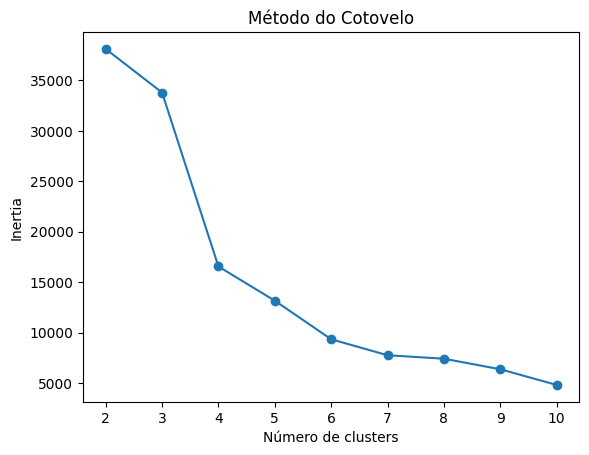

In [38]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Método do Cotovelo')
plt.show()


In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_listings['zone_cluster'] = kmeans.fit_predict(X_scaled)


In [40]:
df_listings['zone_cluster'].value_counts()

,count
zone_cluster,
0,21222
3,8041
2,6598
1,2809


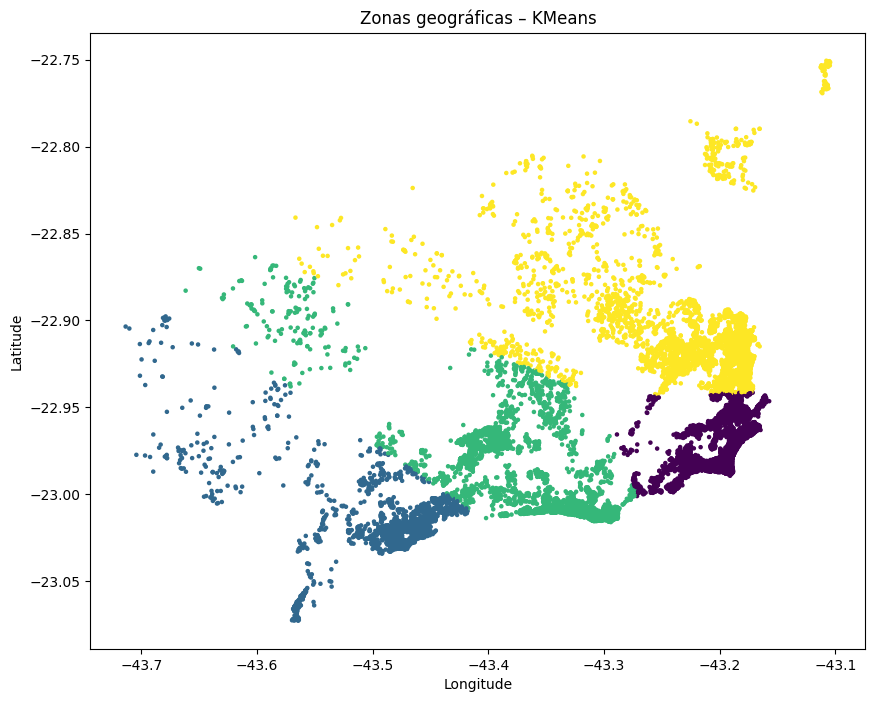

In [41]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df_listings['longitude'],
    df_listings['latitude'],
    c=df_listings['zone_cluster'],
    s=5
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Zonas geográficas – KMeans')
plt.show()

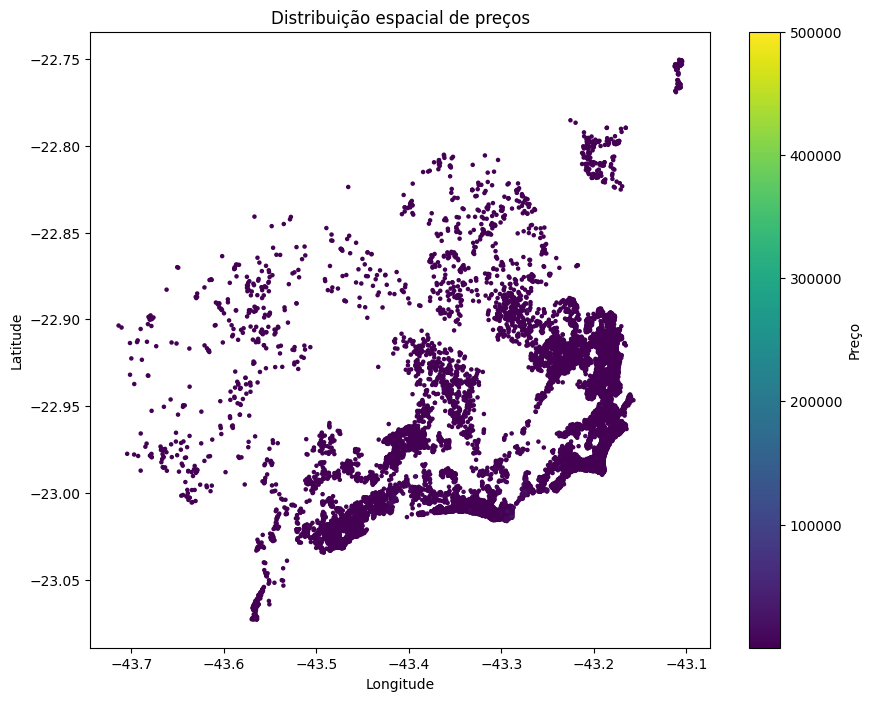

In [42]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df_listings['longitude'],
    df_listings['latitude'],
    c=df_listings['price'],
    s=5
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribuição espacial de preços')
plt.colorbar(label='Preço')
plt.show()

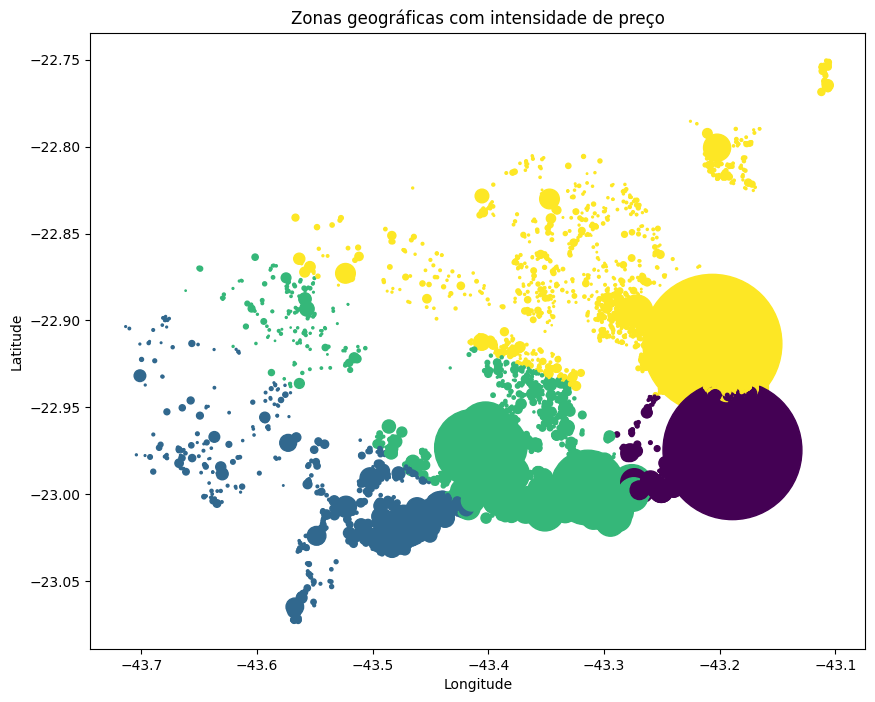

In [43]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df_listings['longitude'],
    df_listings['latitude'],
    c=df_listings['zone_cluster'],
    s=df_listings['price'] / 50  # tamanho proporcional ao preço
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Zonas geográficas com intensidade de preço')
plt.show()




# RESUMO DOS PRINCIPAIS DF

os outros dataframes sao:



```
# df_host = df[[
    'host_id',
    'host_name',
    'host_since',
    'host_is_superhost',
    'host_response_rate',
    'host_acceptance_rate',
    'calculated_host_listings_count'
]]

*desisti de usar esse debaixo*
df_perf = df[[
    'id',
    'price',
    'number_of_reviews',
    'reviews_per_month',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d'
]]


df_quality = df[[
    'id',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'number_of_reviews'
]]

df_avail = df[[
    'id',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365'
]]

```





# Estruturando o df_host

In [44]:
df_host = listings[[
    'host_id',
    'host_name',
    'id',
    'host_since',
    'host_is_superhost',
    'host_response_rate',
    'host_acceptance_rate',
    'calculated_host_listings_count'
]]

In [45]:
df_host.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   host_id                         43068 non-null  int64 
 1   host_name                       43057 non-null  object
 2   id                              43068 non-null  int64 
 3   host_since                      43057 non-null  object
 4   host_is_superhost               41613 non-null  object
 5   host_response_rate              35890 non-null  object
 6   host_acceptance_rate            39327 non-null  object
 7   calculated_host_listings_count  43068 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 2.6+ MB


In [46]:
df_host.head(10)

,host_id,host_name,id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,calculated_host_listings_count
0,84350716,Katrina,821198084644106078,2016-07-17,f,95%,97%,1
1,4347269,Patrick,821198370698658112,2012-12-07,f,100%,46%,2
2,499903412,Vanessa,821200521820144734,2023-02-06,f,NaN,NaN,2
3,449763717,Alvaro,821213014263313420,2022-03-15,f,0%,57%,2
4,25961210,Katia,821223043903573522,2015-01-11,t,100%,71%,1
5,392769753,Amanda,821227099948297881,2021-03-16,t,100%,99%,7
6,498395875,Martha,821240939360008287,2023-01-28,t,100%,90%,1
7,46944465,Ana Lucia,821242614763878451,2015-10-19,f,100%,100%,1
8,15991909,Yona,821254575358803002,2014-05-26,t,100%,73%,3
9,91654021,Daniel,821314145791532025,2016-08-24,f,94%,39%,151


In [47]:
df_host.isnull().sum()

,0
host_id,0
host_name,11
id,0
host_since,11
host_is_superhost,1455
host_response_rate,7178
host_acceptance_rate,3741
calculated_host_listings_count,0


In [48]:
df_host = df_host.copy()


In [49]:
df_host['host_since'] = pd.to_datetime(df_host['host_since']) #transformando a coluna de data do tipo object para datatime64
#

In [50]:
df_host['host_is_superhost'] = df_host['host_is_superhost'].map({ #melhorando a catecorizacao de superhost
    't': 'Superhost',
    'f': 'Regular'
}).fillna('Unknown')

In [51]:
df_host.describe(include='object')

,host_name,host_is_superhost,host_response_rate,host_acceptance_rate
count,43057,43068,35890,39327
unique,7725,3,94,101
top,Daniel,Regular,100%,100%
freq,455,26905,23541,8419


In [52]:
df_host['host_response_rate'] = (             #AJUSTADO AS DUAS COLUNAS DE PORCENTAGEM. ANTES ESTAVAM COMO TEXTO (FOI NECESSARIO TIRAR O %)
    df_host['host_response_rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)

df_host['host_acceptance_rate'] = (
    df_host['host_acceptance_rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)


In [53]:
df_host[['host_response_rate', 'host_acceptance_rate']].describe()


,host_response_rate,host_acceptance_rate
count,35890.000000,39327.000000
mean,87.568794,75.189005
std,26.883424,30.785767
min,0.000000,0.000000
25%,92.000000,60.000000
50%,100.000000,90.000000
75%,100.000000,99.000000
max,100.000000,100.000000


In [54]:
df_host['host_response_rate_prop'] = df_host['host_response_rate'] / 100
df_host['host_acceptance_rate_prop'] = df_host['host_acceptance_rate'] / 100

In [55]:
df_host.head(10)

,host_id,host_name,id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,calculated_host_listings_count,host_response_rate_prop,host_acceptance_rate_prop
0,84350716,Katrina,821198084644106078,2016-07-17,Regular,95.0,97.0,1,0.95,0.97
1,4347269,Patrick,821198370698658112,2012-12-07,Regular,100.0,46.0,2,1.00,0.46
2,499903412,Vanessa,821200521820144734,2023-02-06,Regular,NaN,NaN,2,NaN,NaN
3,449763717,Alvaro,821213014263313420,2022-03-15,Regular,0.0,57.0,2,0.00,0.57
4,25961210,Katia,821223043903573522,2015-01-11,Superhost,100.0,71.0,1,1.00,0.71
5,392769753,Amanda,821227099948297881,2021-03-16,Superhost,100.0,99.0,7,1.00,0.99
6,498395875,Martha,821240939360008287,2023-01-28,Superhost,100.0,90.0,1,1.00,0.90
7,46944465,Ana Lucia,821242614763878451,2015-10-19,Regular,100.0,100.0,1,1.00,1.00
8,15991909,Yona,821254575358803002,2014-05-26,Superhost,100.0,73.0,3,1.00,0.73
9,91654021,Daniel,821314145791532025,2016-08-24,Regular,94.0,39.0,151,0.94,0.39


In [56]:
df_host['host_quality_score'] = (
    0.5 * df_host['host_response_rate_prop'] +
    0.5 * df_host['host_acceptance_rate_prop']
)

#criando uma nova categoria e colocando o mesmo peso para taxa de resposta e aceitação (0,5)


In [57]:
df_host[df_host['host_is_superhost']=='Superhost'].head(5)

,host_id,host_name,id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,calculated_host_listings_count,host_response_rate_prop,host_acceptance_rate_prop,host_quality_score
4,25961210,Katia,821223043903573522,2015-01-11,Superhost,100.0,71.0,1,1.00,0.71,0.855
5,392769753,Amanda,821227099948297881,2021-03-16,Superhost,100.0,99.0,7,1.00,0.99,0.995
6,498395875,Martha,821240939360008287,2023-01-28,Superhost,100.0,90.0,1,1.00,0.90,0.950
8,15991909,Yona,821254575358803002,2014-05-26,Superhost,100.0,73.0,3,1.00,0.73,0.865
12,51227019,Pedro,821640990014497089,2015-12-13,Superhost,96.0,94.0,24,0.96,0.94,0.950


Faixa	Score

* Excelente >=
* Bom	0.75 – 0.89
* Regular	0.60 – 0.74
* Crítico	< 0.60




🧠 Por que isso faz sentido (argumento forte)

0.90+ exige excelência nos dois critérios
Como os pesos são iguais, não dá para “mascarar” um ruim com outro bom.

0.75 é um divisor realista
Abaixo disso, pelo menos um dos critérios já está visivelmente fraco.

0.60 é limite operacional
Abaixo disso, o host já começa a falhar consistentemente.

👉 Isso não é arbitrário: é alinhado ao significado do score.

In [58]:
bins = [0, 0.60, 0.75, 0.90, 1.0]
labels = ['Crítico', 'Regular', 'Bom', 'Excelente']

df_host['host_quality_segment'] = pd.cut(
    df_host['host_quality_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [59]:
df_host['host_quality_segment'].value_counts()

,count
host_quality_segment,
Excelente,20399
Bom,6372
Crítico,5325
Regular,3233


In [60]:
df_host.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   host_id                         43068 non-null  int64         
 1   host_name                       43057 non-null  object        
 2   id                              43068 non-null  int64         
 3   host_since                      43057 non-null  datetime64[ns]
 4   host_is_superhost               43068 non-null  object        
 5   host_response_rate              35890 non-null  float64       
 6   host_acceptance_rate            39327 non-null  float64       
 7   calculated_host_listings_count  43068 non-null  int64         
 8   host_response_rate_prop         35890 non-null  float64       
 9   host_acceptance_rate_prop       39327 non-null  float64       
 10  host_quality_score              35329 non-null  float64       
 11  ho

# Finalizando df_host


# Iniciando o df_quality



In [61]:
df_quality = listings[[
    'id',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_value',
    'review_scores_accuracy',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'number_of_reviews'
]]

In [62]:
df_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           43068 non-null  int64  
 1   review_scores_rating         33882 non-null  float64
 2   review_scores_cleanliness    33882 non-null  float64
 3   review_scores_value          33880 non-null  float64
 4   review_scores_accuracy       33881 non-null  float64
 5   review_scores_checkin        33881 non-null  float64
 6   review_scores_communication  33881 non-null  float64
 7   review_scores_location       33881 non-null  float64
 8   number_of_reviews            43068 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 3.0 MB


In [63]:
df_quality.isnull().sum() #muitas operações sem review

,0
id,0
review_scores_rating,9186
review_scores_cleanliness,9186
review_scores_value,9188
review_scores_accuracy,9187
review_scores_checkin,9187
review_scores_communication,9187
review_scores_location,9187
number_of_reviews,0


In [64]:
df_quality = df_quality.copy()

In [65]:
df_quality.head(15)

,id,review_scores_rating,review_scores_cleanliness,review_scores_value,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,number_of_reviews
0,821198084644106078,4.93,4.99,4.85,4.97,4.97,4.94,4.99,86
1,821198370698658112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,821200521820144734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,821213014263313420,5.00,4.67,4.67,4.67,5.00,5.00,5.00,3
4,821223043903573522,4.91,4.82,5.00,5.00,5.00,5.00,5.00,11
5,821227099948297881,4.93,4.88,4.85,4.93,4.94,4.99,4.94,89
6,821240939360008287,4.91,4.93,4.87,4.93,4.97,4.99,4.99,68
7,821242614763878451,4.78,4.87,4.70,4.83,5.00,5.00,5.00,23
8,821254575358803002,5.00,5.00,5.00,5.00,5.00,5.00,4.88,8
9,821314145791532025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [66]:
score_cols = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_value',
    'review_scores_accuracy',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
]

df_quality['mean_score'] = df_quality[score_cols].mean(axis=1)

#CALCULANDO A MÉDIA DE AVALIAÇÃO e criando uma nova coluna `mean_score


In [67]:
df_quality.head(10)

,id,review_scores_rating,review_scores_cleanliness,review_scores_value,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,number_of_reviews,mean_score
0,821198084644106078,4.93,4.99,4.85,4.97,4.97,4.94,4.99,86,4.948571
1,821198370698658112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,821200521820144734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,821213014263313420,5.00,4.67,4.67,4.67,5.00,5.00,5.00,3,4.858571
4,821223043903573522,4.91,4.82,5.00,5.00,5.00,5.00,5.00,11,4.961429
5,821227099948297881,4.93,4.88,4.85,4.93,4.94,4.99,4.94,89,4.922857
6,821240939360008287,4.91,4.93,4.87,4.93,4.97,4.99,4.99,68,4.941429
7,821242614763878451,4.78,4.87,4.70,4.83,5.00,5.00,5.00,23,4.882857
8,821254575358803002,5.00,5.00,5.00,5.00,5.00,5.00,4.88,8,4.982857
9,821314145791532025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [68]:
df_quality[['mean_score', 'number_of_reviews']].describe()


,mean_score,number_of_reviews
count,33882.000000,43068.000000
mean,4.824819,26.184545
std,0.298951,48.648266
min,1.000000,0.000000
25%,4.794286,1.000000
50%,4.900000,7.000000
75%,4.965714,30.000000
max,5.000000,760.000000


In [69]:
df_quality_ml = df_quality[
    (df_quality['number_of_reviews'] > 0) &
    (df_quality['mean_score'].notna())
].copy()


In [70]:
m = 20  # mínimo de reviews para "confiar"
C = df_quality_ml['mean_score'].mean()

df_quality_ml['bayesian_score'] = (
    df_quality_ml['number_of_reviews'] * df_quality_ml['mean_score'] + m * C
) / (df_quality_ml['number_of_reviews'] + m)


In [71]:
import numpy as np

df_quality_ml['reviews_log'] = np.log1p(df_quality_ml['number_of_reviews'])


In [72]:
X = df_quality_ml[['bayesian_score', 'reviews_log']]


In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [74]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,     # ajuste conforme tamanho do dataset
    min_samples=10,          # quão conservador o cluster deve ser
    metric='euclidean'
)

df_quality_ml['cluster'] = clusterer.fit_predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [75]:
df_quality_ml['cluster'].value_counts()


,count
cluster,
100,13804
-1,5351
0,2344
13,1143
19,695
...,...
64,51
22,51
92,51


In [76]:
df_valid = df_quality_ml[df_quality_ml['cluster'] != -1]


In [77]:
df_valid.groupby('cluster')[[
    'mean_score',
    'number_of_reviews'
]].agg(['mean', 'median', 'count'])


mean_score                  number_of_reviews              
              mean    median  count              mean median  count
cluster                                                            
0         5.000000  5.000000   2344          1.000000    1.0   2344
1         4.857143  4.857143    363          1.000000    1.0    363
2         4.428571  4.428571     92          1.000000    1.0     92
3         4.285714  4.285714     71          1.000000    1.0     71
4         4.571429  4.571429    143          1.000000    1.0    143
...            ...       ...    ...               ...    ...    ...
96        4.769775  4.770000     89         81.370787   81.0     89
97        4.942748  4.941429     92         12.000000   12.0     92
98        4.911171  4.907143     50         12.000000   12.0     50
99        4.830368  4.832857    128         12.000000   12.0    128
100       4.891824  4.904286  13804         46.621052   34.5  13804

[101 rows x 6 columns]

In [78]:
rules = [
    {'name': 'Ruído / Outliers', 'cond': df_quality_ml['cluster'] == -1},
    {'name': 'Risco de Experiência', 'cond': df_quality_ml['mean_score'] < 4.0},
    {'name': 'Promissores Não Validados',
     'cond': (df_quality_ml['mean_score'] >= 4.2) & (df_quality_ml['number_of_reviews'] <= 2)},
    {'name': 'Alta Qualidade Emergente',
     'cond': (df_quality_ml['mean_score'] >= 4.7) & (df_quality_ml['number_of_reviews'] <= 30)}
]

df_quality_ml['quality_zone'] = 'Mercado Maduro Premium'

for rule in rules:
    df_quality_ml.loc[rule['cond'], 'quality_zone'] = rule['name']


| Zona                         | Critério                                                  |
| ---------------------------- | --------------------------------------------------------- |
| ⚫ Ruído                      | `cluster == -1`                                           |
| 🔴 Risco de Experiência      | `mean_score < 4.0`                                        |
| 🟡 Promissores Não Validados | `mean_score ≥ 4.2` **e** `number_of_reviews ≤ 2`          |
| 🟢 Alta Qualidade Emergente  | `mean_score ≥ 4.7` **e** `number_of_reviews entre 3 e 30` |
| 🔵 Mercado Maduro Premium    | `mean_score ≥ 4.7` **e** `number_of_reviews > 30`         |


In [79]:
df_quality_ml['quality_zone'].value_counts()

,count
quality_zone,
Alta Qualidade Emergente,19263
Mercado Maduro Premium,9506
Ruído / Outliers,3910
Promissores Não Validados,611
Risco de Experiência,592


In [80]:
df_quality_ml.head(5)

,id,review_scores_rating,review_scores_cleanliness,review_scores_value,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,number_of_reviews,mean_score,bayesian_score,reviews_log,cluster,quality_zone
0,821198084644106078,4.93,4.99,4.85,4.97,4.97,4.94,4.99,86,4.948571,4.925222,4.465908,100,Mercado Maduro Premium
3,821213014263313420,5.00,4.67,4.67,4.67,5.00,5.00,5.00,3,4.858571,4.829221,1.386294,24,Alta Qualidade Emergente
4,821223043903573522,4.91,4.82,5.00,5.00,5.00,5.00,5.00,11,4.961429,4.873293,2.484907,95,Alta Qualidade Emergente
5,821227099948297881,4.93,4.88,4.85,4.93,4.94,4.99,4.94,89,4.922857,4.904868,4.499810,100,Mercado Maduro Premium
6,821240939360008287,4.91,4.93,4.87,4.93,4.97,4.99,4.99,68,4.941429,4.914926,4.234107,100,Mercado Maduro Premium


In [81]:
df_quality_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33882 entries, 0 to 43000
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           33882 non-null  int64  
 1   review_scores_rating         33882 non-null  float64
 2   review_scores_cleanliness    33882 non-null  float64
 3   review_scores_value          33880 non-null  float64
 4   review_scores_accuracy       33881 non-null  float64
 5   review_scores_checkin        33881 non-null  float64
 6   review_scores_communication  33881 non-null  float64
 7   review_scores_location       33881 non-null  float64
 8   number_of_reviews            33882 non-null  int64  
 9   mean_score                   33882 non-null  float64
 10  bayesian_score               33882 non-null  float64
 11  reviews_log                  33882 non-null  float64
 12  cluster                      33882 non-null  int64  
 13  quality_zone         

# Tratando o df_amenities

In [82]:
listings['amenities'].head(30)
#

,amenities
0,"[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,"[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,"[""BBQ grill"", ""Exterior security cameras on pr..."
3,"[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,"[""Outdoor shower"", ""Pool"", ""Free parking on pr..."
5,"[""Hangers"", ""Wine glasses"", ""Essentials"", ""Din..."
6,"[""Hangers"", ""Essentials"", ""Dining table"", ""Dry..."
7,"[""Wine glasses"", ""Hammock"", ""Essentials"", ""Din..."
8,"[""Hangers"", ""Essentials"", ""Drying rack for clo..."
9,"[""Hangers"", ""Smoking allowed"", ""Essentials"", ""..."


In [83]:
import ast

listings['amenities_list'] = listings['amenities'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)


In [84]:
type(listings.loc[0, 'amenities_list'])
# list


list

In [85]:
listings['amenities_list'].apply(type).value_counts()


,count
amenities_list,
<class 'list'>,43068


In [86]:
listings['amenities_list'].apply(len).describe()


,amenities_list
count,43068.000000
mean,25.033134
std,14.707054
min,0.000000
25%,12.000000
50%,24.000000
75%,35.000000
max,115.000000


In [87]:
df_amenities = listings[[
    'id',
    'amenities_list',
    'amenities'
]]

#

In [88]:
df_amenities.head(10)

,id,amenities_list,amenities
0,821198084644106078,"[Hangers, Hot water kettle, Wine glasses, Hamm...","[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,821198370698658112,"[Smoking allowed, TV, Kitchen, Washer, Wifi, A...","[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,821200521820144734,"[BBQ grill, Exterior security cameras on prope...","[""BBQ grill"", ""Exterior security cameras on pr..."
3,821213014263313420,"[Essentials, Hair dryer, Cooking basics, Dishe...","[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,821223043903573522,"[Outdoor shower, Pool, Free parking on premise...","[""Outdoor shower"", ""Pool"", ""Free parking on pr..."
5,821227099948297881,"[Hangers, Wine glasses, Essentials, Dining tab...","[""Hangers"", ""Wine glasses"", ""Essentials"", ""Din..."
6,821240939360008287,"[Hangers, Essentials, Dining table, Drying rac...","[""Hangers"", ""Essentials"", ""Dining table"", ""Dry..."
7,821242614763878451,"[Wine glasses, Hammock, Essentials, Dining tab...","[""Wine glasses"", ""Hammock"", ""Essentials"", ""Din..."
8,821254575358803002,"[Hangers, Essentials, Drying rack for clothing...","[""Hangers"", ""Essentials"", ""Drying rack for clo..."
9,821314145791532025,"[Hangers, Smoking allowed, Essentials, Hot wat...","[""Hangers"", ""Smoking allowed"", ""Essentials"", ""..."


In [89]:
df_amenities = df_amenities.copy()

In [90]:
df_amenities["amenities_count"] = df_amenities["amenities_list"].apply(len)

In [91]:
amenities_map = {
    "has_wifi": ["Wifi"],
    "has_air_conditioning": ["Air conditioning", "AC"],
    "has_kitchen": ["Kitchen"],
    "has_washer": ["Washer"],
    "has_parking": ["Free parking", "Paid parking"],
    "has_pool": ["Pool"],
    "has_workspace": ["Dedicated workspace"],
    "has_tv": ["TV"]
}

In [92]:
for col, keywords in amenities_map.items():
    df_amenities[col] = df_amenities["amenities"].apply(
        lambda x: int(any(k in x for k in keywords))
    )


In [93]:
feature_cols = list(amenities_map.keys())

df_amenities["amenities_score"] = df_amenities[feature_cols].sum(axis=1)


In [94]:
df_amenities_exploded = (
    df_amenities[["id", "amenities"]]
    .explode("amenities")
    .rename(columns={"amenities": "amenity"})
    .reset_index(drop=True)
)


In [95]:
df_amenities_exploded.head(10)
#

,id,amenity
0,821198084644106078,"[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,821198370698658112,"[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,821200521820144734,"[""BBQ grill"", ""Exterior security cameras on pr..."
3,821213014263313420,"[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,821223043903573522,"[""Outdoor shower"", ""Pool"", ""Free parking on pr..."
5,821227099948297881,"[""Hangers"", ""Wine glasses"", ""Essentials"", ""Din..."
6,821240939360008287,"[""Hangers"", ""Essentials"", ""Dining table"", ""Dry..."
7,821242614763878451,"[""Wine glasses"", ""Hammock"", ""Essentials"", ""Din..."
8,821254575358803002,"[""Hangers"", ""Essentials"", ""Drying rack for clo..."
9,821314145791532025,"[""Hangers"", ""Smoking allowed"", ""Essentials"", ""..."



```
deu ruim aqui em cima, nao veio explodido
```



In [96]:
import ast

df_amenities["amenities"] = df_amenities["amenities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


In [97]:
df_amenities["amenities"].apply(type).value_counts()


,count
amenities,
<class 'list'>,43068


In [98]:
df_amenities_exploded = (
    df_amenities[["id", "amenities"]]
    .explode("amenities")
    .rename(columns={"amenities": "amenity"})
    .reset_index(drop=True)
)


In [99]:
df_amenities_exploded.head(50)


,id,amenity
0,821198084644106078,Hangers
1,821198084644106078,Hot water kettle
2,821198084644106078,Wine glasses
3,821198084644106078,Hammock
4,821198084644106078,Outdoor shower
5,821198084644106078,Essentials
6,821198084644106078,Drying rack for clothing
7,821198084644106078,Dining table
8,821198084644106078,Beach essentials
9,821198084644106078,Bed linens


In [100]:
df_amenities_exploded["amenity"].value_counts().head(50)


,count
amenity,
Kitchen,38992
Wifi,38947
Hot water,27926
TV,26871
Air conditioning,26856
Dishes and silverware,26668
Bed linens,26050
Iron,25209
Hangers,25067


In [101]:
df_amenities_exploded['amenity'].describe()

,amenity
count,1078127
unique,7024
top,Kitchen
freq,38992


In [102]:
amenity_freq = (
    df_amenities_exploded
    .groupby("amenity")["id"]
    .nunique()
    .sort_values(ascending=False)
)


In [103]:
total_listings = df_amenities_exploded["id"].nunique()

amenity_share = amenity_freq / total_listings

In [104]:
df_amenities_exploded.head(5)

,id,amenity
0,821198084644106078,Hangers
1,821198084644106078,Hot water kettle
2,821198084644106078,Wine glasses
3,821198084644106078,Hammock
4,821198084644106078,Outdoor shower


In [105]:
df_amenities_exploded["amenity_penetration"] = (
    df_amenities_exploded["amenity"]
    .map(amenity_share)
)


In [106]:
def market_category(p):
    if p >= 0.7:
        return "Essencial"
    elif p >= 0.3:
        return "Padrão"
    elif p >= 0.1:
        return "Diferencial"
    else:
        return "Nicho"


In [107]:
df_amenities_exploded["market_category"] = (
    df_amenities_exploded["amenity_penetration"]
    .apply(market_category)
)


In [108]:
df_amenities_exploded.sort_values(by="amenity_penetration",ascending=False).head(10)
#

,id,amenity,amenity_penetration,market_category
1078221,1518231484245289234,Kitchen,0.905359,Essencial
1078201,1518205167366521069,Kitchen,0.905359,Essencial
792971,1264675145848441473,Kitchen,0.905359,Essencial
792942,1264662121514690599,Kitchen,0.905359,Essencial
65,821200521820144734,Kitchen,0.905359,Essencial
25,821198084644106078,Kitchen,0.905359,Essencial
1078181,1518196386170851837,Kitchen,0.905359,Essencial
309832,50310550,Kitchen,0.905359,Essencial
309782,50277796,Kitchen,0.905359,Essencial
309823,50300124,Kitchen,0.905359,Essencial


In [109]:
df_amenity_analysis = (
    df_amenities_exploded
        .groupby("amenity")
        .agg(
            amenity_penetration=("amenity_penetration", "mean"),
            market_category=("market_category", "first"),
            total_listings=("id", "nunique")
        )
        .reset_index()
        .sort_values("amenity_penetration", ascending=False)
)


In [110]:
df_amenity_analysis.sort_values("amenity_penetration", ascending=False).head(50)

,amenity,amenity_penetration,market_category,total_listings
5050,Kitchen,0.905359,Essencial,38992
6947,Wifi,0.904314,Essencial,38947
4508,Hot water,0.648416,Padrão,27926
6638,TV,0.623920,Padrão,26871
1706,Air conditioning,0.623572,Padrão,26856
2658,Dishes and silverware,0.619207,Padrão,26668
1893,Bed linens,0.604857,Padrão,26050
4976,Iron,0.585330,Padrão,25209
4469,Hangers,0.582033,Padrão,25067
2486,Cooking basics,0.562529,Padrão,24227


# Iniciando tratamento de Df_avail

In [111]:
df_avail = listings[[ 'id','availability_30', 'availability_60', 'availability_90', 'availability_365','latitude', 'longitude' ]]

In [112]:
df_avail.head(15)

,id,availability_30,availability_60,availability_90,availability_365,latitude,longitude
0,821198084644106078,6,9,24,82,-22.982818,-43.222457
1,821198370698658112,29,59,89,364,-22.984090,-43.191770
2,821200521820144734,30,60,90,365,-22.814911,-43.379011
3,821213014263313420,0,0,0,0,-22.981910,-43.225990
4,821223043903573522,19,49,72,234,-23.010000,-43.344820
5,821227099948297881,23,45,70,113,-22.970696,-43.186048
6,821240939360008287,0,0,0,0,-22.980368,-43.223114
7,821242614763878451,4,12,15,32,-22.963629,-43.172243
8,821254575358803002,29,59,89,89,-22.976303,-43.194838
9,821314145791532025,30,60,90,90,-22.940620,-43.181620


In [113]:
df_avail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                43068 non-null  int64  
 1   availability_30   43068 non-null  int64  
 2   availability_60   43068 non-null  int64  
 3   availability_90   43068 non-null  int64  
 4   availability_365  43068 non-null  int64  
 5   latitude          43068 non-null  float64
 6   longitude         43068 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 2.3 MB


In [114]:
df_avail = df_avail.copy()

In [115]:
df_avail['fully_blocked'] = (df_avail['availability_365'] == 0).astype(int)


In [116]:
df_avail['fully_blocked'] = df_avail['fully_blocked'].map({
    0: 'Disponível',
    1: 'Indisponível'
})

In [117]:
df_avail.head(10)

,id,availability_30,availability_60,availability_90,availability_365,latitude,longitude,fully_blocked
0,821198084644106078,6,9,24,82,-22.982818,-43.222457,Disponível
1,821198370698658112,29,59,89,364,-22.984090,-43.191770,Disponível
2,821200521820144734,30,60,90,365,-22.814911,-43.379011,Disponível
3,821213014263313420,0,0,0,0,-22.981910,-43.225990,Indisponível
4,821223043903573522,19,49,72,234,-23.010000,-43.344820,Disponível
5,821227099948297881,23,45,70,113,-22.970696,-43.186048,Disponível
6,821240939360008287,0,0,0,0,-22.980368,-43.223114,Indisponível
7,821242614763878451,4,12,15,32,-22.963629,-43.172243,Disponível
8,821254575358803002,29,59,89,89,-22.976303,-43.194838,Disponível
9,821314145791532025,30,60,90,90,-22.940620,-43.181620,Disponível


In [118]:
df_avail.value_counts('fully_blocked')
#

,count
fully_blocked,
Disponível,39868
Indisponível,3200


In [119]:
df_avail['occ_rate_30']  = 1 - (df_avail['availability_30']  / 30)
df_avail['occ_rate_60']  = 1 - (df_avail['availability_60']  / 60)
df_avail['occ_rate_90']  = 1 - (df_avail['availability_90']  / 90)
df_avail['occ_rate_365'] = 1 - (df_avail['availability_365'] / 365)


In [120]:
df_avail.head(10)

,id,availability_30,availability_60,availability_90,availability_365,latitude,longitude,fully_blocked,occ_rate_30,occ_rate_60,occ_rate_90,occ_rate_365
0,821198084644106078,6,9,24,82,-22.982818,-43.222457,Disponível,0.800000,0.850000,0.733333,0.775342
1,821198370698658112,29,59,89,364,-22.984090,-43.191770,Disponível,0.033333,0.016667,0.011111,0.002740
2,821200521820144734,30,60,90,365,-22.814911,-43.379011,Disponível,0.000000,0.000000,0.000000,0.000000
3,821213014263313420,0,0,0,0,-22.981910,-43.225990,Indisponível,1.000000,1.000000,1.000000,1.000000
4,821223043903573522,19,49,72,234,-23.010000,-43.344820,Disponível,0.366667,0.183333,0.200000,0.358904
5,821227099948297881,23,45,70,113,-22.970696,-43.186048,Disponível,0.233333,0.250000,0.222222,0.690411
6,821240939360008287,0,0,0,0,-22.980368,-43.223114,Indisponível,1.000000,1.000000,1.000000,1.000000
7,821242614763878451,4,12,15,32,-22.963629,-43.172243,Disponível,0.866667,0.800000,0.833333,0.912329
8,821254575358803002,29,59,89,89,-22.976303,-43.194838,Disponível,0.033333,0.016667,0.011111,0.756164
9,821314145791532025,30,60,90,90,-22.940620,-43.181620,Disponível,0.000000,0.000000,0.000000,0.753425


In [121]:
df_avail['occ_index'] = (
    df_avail['occ_rate_30']  * 0.4 +
    df_avail['occ_rate_60']  * 0.3 +
    df_avail['occ_rate_90']  * 0.2 +
    df_avail['occ_rate_365'] * 0.1
)

In [122]:
df_avail['occ_level'] = pd.cut( #ele nao pegava o limite inferior, sendo nessário ajustar para um valor negativo
    df_avail['occ_index'],
    bins=[-0.00001, 0.3, 0.6, 0.8, 1.0],
    labels=[
        'Baixa ocupação',
        'Ocupação média',
        'Alta ocupação',
        'Ocupação crítica'
    ]
)


In [123]:
df_avail.head(20)

,id,availability_30,availability_60,availability_90,availability_365,latitude,longitude,fully_blocked,occ_rate_30,occ_rate_60,occ_rate_90,occ_rate_365,occ_index,occ_level
0,821198084644106078,6,9,24,82,-22.982818,-43.222457,Disponível,0.800000,0.850000,0.733333,0.775342,0.799201,Alta ocupação
1,821198370698658112,29,59,89,364,-22.984090,-43.191770,Disponível,0.033333,0.016667,0.011111,0.002740,0.020830,Baixa ocupação
2,821200521820144734,30,60,90,365,-22.814911,-43.379011,Disponível,0.000000,0.000000,0.000000,0.000000,0.000000,Baixa ocupação
3,821213014263313420,0,0,0,0,-22.981910,-43.225990,Indisponível,1.000000,1.000000,1.000000,1.000000,1.000000,Ocupação crítica
4,821223043903573522,19,49,72,234,-23.010000,-43.344820,Disponível,0.366667,0.183333,0.200000,0.358904,0.277557,Baixa ocupação
5,821227099948297881,23,45,70,113,-22.970696,-43.186048,Disponível,0.233333,0.250000,0.222222,0.690411,0.281819,Baixa ocupação
6,821240939360008287,0,0,0,0,-22.980368,-43.223114,Indisponível,1.000000,1.000000,1.000000,1.000000,1.000000,Ocupação crítica
7,821242614763878451,4,12,15,32,-22.963629,-43.172243,Disponível,0.866667,0.800000,0.833333,0.912329,0.844566,Ocupação crítica
8,821254575358803002,29,59,89,89,-22.976303,-43.194838,Disponível,0.033333,0.016667,0.011111,0.756164,0.096172,Baixa ocupação
9,821314145791532025,30,60,90,90,-22.940620,-43.181620,Disponível,0.000000,0.000000,0.000000,0.753425,0.075342,Baixa ocupação


In [124]:
df_avail.value_counts('occ_level')

,count
occ_level,
Baixa ocupação,22739
Ocupação crítica,8449
Ocupação média,7663
Alta ocupação,4217


In [125]:
map_df = df_avail[['latitude', 'longitude', 'occ_index']].dropna()


In [126]:
import folium
from folium.plugins import HeatMap

# Centro do mapa
center_lat = map_df['latitude'].mean()
center_lon = map_df['longitude'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)

HeatMap(
    data=map_df[['latitude', 'longitude', 'occ_index']].values,
    radius=12,
    blur=18,
    max_zoom=13
).add_to(m)

m


# Download dos CSVs

In [127]:
#df_valid.to_csv('df_valid.csv', index=False)
#df_amenities_exploded.to_csv('df_amenities_exploded.csv', index=False)
#df_avail.to_csv('df_avail.csv', index=False)

In [128]:
#df_host.to_csv('df_host.csv', index=False)
#df_listings.to_csv('df_listings.csv', index=False)
#df_quality_ml.to_csv('df_quality_ml.csv', index=False)
#df_amenity_analysis.to_csv('df_amenity_analysis.csv', index=False)

In [129]:
from pandas.io import sql

print(sql.get_schema(df_host, "df_host"))

CREATE TABLE "df_host" (
"host_id" INTEGER,
  "host_name" TEXT,
  "id" INTEGER,
  "host_since" TIMESTAMP,
  "host_is_superhost" TEXT,
  "host_response_rate" REAL,
  "host_acceptance_rate" REAL,
  "calculated_host_listings_count" INTEGER,
  "host_response_rate_prop" REAL,
  "host_acceptance_rate_prop" REAL,
  "host_quality_score" REAL,
  "host_quality_segment" TEXT
)


In [130]:
df_quality_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33882 entries, 0 to 43000
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           33882 non-null  int64  
 1   review_scores_rating         33882 non-null  float64
 2   review_scores_cleanliness    33882 non-null  float64
 3   review_scores_value          33880 non-null  float64
 4   review_scores_accuracy       33881 non-null  float64
 5   review_scores_checkin        33881 non-null  float64
 6   review_scores_communication  33881 non-null  float64
 7   review_scores_location       33881 non-null  float64
 8   number_of_reviews            33882 non-null  int64  
 9   mean_score                   33882 non-null  float64
 10  bayesian_score               33882 non-null  float64
 11  reviews_log                  33882 non-null  float64
 12  cluster                      33882 non-null  int64  
 13  quality_zone         

In [131]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28531 entries, 0 to 43000
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           28531 non-null  int64  
 1   review_scores_rating         28531 non-null  float64
 2   review_scores_cleanliness    28531 non-null  float64
 3   review_scores_value          28529 non-null  float64
 4   review_scores_accuracy       28530 non-null  float64
 5   review_scores_checkin        28530 non-null  float64
 6   review_scores_communication  28530 non-null  float64
 7   review_scores_location       28530 non-null  float64
 8   number_of_reviews            28531 non-null  int64  
 9   mean_score                   28531 non-null  float64
 10  bayesian_score               28531 non-null  float64
 11  reviews_log                  28531 non-null  float64
 12  cluster                      28531 non-null  int64  
dtypes: float64(10), int64

In [132]:
df_listings

,id,host_id,host_name,name,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,price_segment,latitude,longitude,zone_cluster
0,821198084644106078,84350716,Katrina,Bright and Peaceful Leblon Loft,Leblon,Entire home/apt,Entire condo,580.0,4,2.0,3.0,Intermediário,-22.982818,-43.222457,0
1,821198370698658112,4347269,Patrick,Copacabana 100% reformado.,Copacabana,Entire home/apt,Entire rental unit,1900.0,2,1.0,1.0,Alto padrão,-22.984090,-43.191770,0
2,821200521820144734,499903412,Vanessa,hambiente familia,Pavuna,Entire home/apt,Entire rental unit,700.0,4,1.0,1.0,Intermediário,-22.814911,-43.379011,3
3,821223043903573522,25961210,Katia,Incrível apartamento frente mar,Barra da Tijuca,Entire home/apt,Entire rental unit,500.0,4,1.0,1.0,Padrão,-23.010000,-43.344820,2
4,821227099948297881,392769753,Amanda,Apt N S de Copacabana reformado!,Copacabana,Entire home/apt,Entire rental unit,461.0,6,2.0,6.0,Padrão,-22.970696,-43.186048,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38665,1518122747519424376,113997985,HomeRio,Comfort just 300m from Arpoador Beach,Ipanema,Entire home/apt,Entire rental unit,565.0,2,1.0,1.0,Intermediário,-22.987120,-43.192690,0
38666,1518126799366691867,407249643,Edilon Silva,Quarto em Botafogo,Botafogo,Private room,Private room in home,95.0,2,1.0,1.0,Econômico,-22.952837,-43.194664,0
38667,1518196386170851837,55406456,Brunno,Pé na areia - Praia de Copacabana,Copacabana,Entire home/apt,Entire rental unit,204.0,2,1.0,1.0,Padrão,-22.967640,-43.183030,0
38668,1518205167366521069,463749175,Sophia,Quarto em Botafogo perto de pontos turísticos,Botafogo,Private room,Private room in home,112.0,1,1.0,2.0,Econômico,-22.951844,-43.194001,0


In [133]:
df_listings.head()

,id,host_id,host_name,name,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,price_segment,latitude,longitude,zone_cluster
0,821198084644106078,84350716,Katrina,Bright and Peaceful Leblon Loft,Leblon,Entire home/apt,Entire condo,580.0,4,2.0,3.0,Intermediário,-22.982818,-43.222457,0
1,821198370698658112,4347269,Patrick,Copacabana 100% reformado.,Copacabana,Entire home/apt,Entire rental unit,1900.0,2,1.0,1.0,Alto padrão,-22.984090,-43.191770,0
2,821200521820144734,499903412,Vanessa,hambiente familia,Pavuna,Entire home/apt,Entire rental unit,700.0,4,1.0,1.0,Intermediário,-22.814911,-43.379011,3
3,821223043903573522,25961210,Katia,Incrível apartamento frente mar,Barra da Tijuca,Entire home/apt,Entire rental unit,500.0,4,1.0,1.0,Padrão,-23.010000,-43.344820,2
4,821227099948297881,392769753,Amanda,Apt N S de Copacabana reformado!,Copacabana,Entire home/apt,Entire rental unit,461.0,6,2.0,6.0,Padrão,-22.970696,-43.186048,0


In [134]:
df_quality_ml.head()

,id,review_scores_rating,review_scores_cleanliness,review_scores_value,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_location,number_of_reviews,mean_score,bayesian_score,reviews_log,cluster,quality_zone
0,821198084644106078,4.93,4.99,4.85,4.97,4.97,4.94,4.99,86,4.948571,4.925222,4.465908,100,Mercado Maduro Premium
3,821213014263313420,5.00,4.67,4.67,4.67,5.00,5.00,5.00,3,4.858571,4.829221,1.386294,24,Alta Qualidade Emergente
4,821223043903573522,4.91,4.82,5.00,5.00,5.00,5.00,5.00,11,4.961429,4.873293,2.484907,95,Alta Qualidade Emergente
5,821227099948297881,4.93,4.88,4.85,4.93,4.94,4.99,4.94,89,4.922857,4.904868,4.499810,100,Mercado Maduro Premium
6,821240939360008287,4.91,4.93,4.87,4.93,4.97,4.99,4.99,68,4.941429,4.914926,4.234107,100,Mercado Maduro Premium


In [135]:
df_quality_ml = df_quality_ml[
    df_quality_ml["id"].isin(df_listings["id"])
]

In [136]:
assert df_quality_ml["id"].isin(df_listings["id"]).all()

In [137]:
df_amenities_exploded = df_amenities_exploded [
    df_amenities_exploded ["id"].isin(df_listings["id"])
]

In [138]:
assert df_amenities_exploded["id"].isin(df_listings["id"]).all()

In [139]:
df_host = df_host [
    df_host ["id"].isin(df_listings["id"])
]

In [140]:
assert df_host["id"].isin(df_listings["id"]).all()

In [141]:
df_avail = df_avail [
    df_avail ["id"].isin(df_listings["id"])
]

In [142]:
assert df_avail["id"].isin(df_listings["id"]).all()

In [143]:
df_listings.to_csv("listings_clean.csv", index=False)

df_quality_ml.to_csv("quality_clean.csv", index=False)

df_amenities_exploded.to_csv("amenities_clean.csv", index=False)

df_host.to_csv("hosts_clean.csv", index=False)

df_avail.to_csv("availability_clean.csv", index=False)

In [144]:
df_host.dtypes

,0
host_id,int64
host_name,object
id,int64
host_since,datetime64[ns]
host_is_superhost,object
host_response_rate,float64
host_acceptance_rate,float64
calculated_host_listings_count,int64
host_response_rate_prop,float64
host_acceptance_rate_prop,float64


In [145]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///airbnb.db")

In [146]:
df_quality_ml.to_sql("quality", engine, if_exists="replace", index=False)

df_amenities_exploded.to_sql("amenities", engine, if_exists="replace", index=False)

df_host.to_sql("hosts", engine, if_exists="replace", index=False)

df_avail.to_sql("availability", engine, if_exists="replace", index=False)

38670

In [147]:
df_listings.to_sql("listings", engine, if_exists="replace", index=False)

38670

In [148]:
df_host = df_host.drop(columns=["id"])

In [149]:
print(sql.get_schema(df_host, "host"))

CREATE TABLE "host" (
"host_id" INTEGER,
  "host_name" TEXT,
  "host_since" TIMESTAMP,
  "host_is_superhost" TEXT,
  "host_response_rate" REAL,
  "host_acceptance_rate" REAL,
  "calculated_host_listings_count" INTEGER,
  "host_response_rate_prop" REAL,
  "host_acceptance_rate_prop" REAL,
  "host_quality_score" REAL,
  "host_quality_segment" TEXT
)


In [150]:
print(sql.get_schema(df_listings,"listings"))

CREATE TABLE "listings" (
"id" INTEGER,
  "host_id" INTEGER,
  "host_name" TEXT,
  "name" TEXT,
  "neighbourhood_cleansed" TEXT,
  "room_type" TEXT,
  "property_type" TEXT,
  "price" REAL,
  "accommodates" INTEGER,
  "bedrooms" REAL,
  "beds" REAL,
  "price_segment" TEXT,
  "latitude" REAL,
  "longitude" REAL,
  "zone_cluster" INTEGER
)


In [151]:
print(sql.get_schema(df_avail,"availability"))

CREATE TABLE "availability" (
"id" INTEGER,
  "availability_30" INTEGER,
  "availability_60" INTEGER,
  "availability_90" INTEGER,
  "availability_365" INTEGER,
  "latitude" REAL,
  "longitude" REAL,
  "fully_blocked" TEXT,
  "occ_rate_30" REAL,
  "occ_rate_60" REAL,
  "occ_rate_90" REAL,
  "occ_rate_365" REAL,
  "occ_index" REAL,
  "occ_level" TEXT
)


In [152]:
print(sql.get_schema(df_quality_ml,"quality"))

CREATE TABLE "quality" (
"id" INTEGER,
  "review_scores_rating" REAL,
  "review_scores_cleanliness" REAL,
  "review_scores_value" REAL,
  "review_scores_accuracy" REAL,
  "review_scores_checkin" REAL,
  "review_scores_communication" REAL,
  "review_scores_location" REAL,
  "number_of_reviews" INTEGER,
  "mean_score" REAL,
  "bayesian_score" REAL,
  "reviews_log" REAL,
  "cluster" INTEGER,
  "quality_zone" TEXT
)


In [153]:
print(sql.get_schema(df_amenities_exploded,"amenities"))

CREATE TABLE "amenities" (
"id" INTEGER,
  "amenity" TEXT,
  "amenity_penetration" REAL,
  "market_category" TEXT
)


In [154]:
df_amenities_exploded.head()

,id,amenity,amenity_penetration,market_category
0,821198084644106078,Hangers,0.582033,Padrão
1,821198084644106078,Hot water kettle,0.142171,Diferencial
2,821198084644106078,Wine glasses,0.309000,Padrão
3,821198084644106078,Hammock,0.057212,Nicho
4,821198084644106078,Outdoor shower,0.135553,Diferencial


In [155]:
df_host.to_csv("hosts.csv", index=False)

In [156]:
df_host.duplicated(subset="host_id").sum()

np.int64(16047)

In [157]:
df_host["host_id"].nunique() # HAVIA HOST_ID DUPLICADOS E ISSO QUEBRAVA NO BANCO CONSIDERANDO Q ERA A PRIMARY KEY

22623

In [158]:
len(df_host)

38670

In [159]:
df_host = df_host.drop_duplicates(subset="host_id") #removendo as duplicados de host_id

In [162]:
df_listings['price'].describe()

,price
count,38670.000000
mean,717.535325
std,4388.082802
min,30.000000
25%,202.000000
50%,317.000000
75%,565.000000
max,500000.000000


In [164]:
df_host['calculated_host_listings_count']

,host_id,host_name,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,calculated_host_listings_count,host_response_rate_prop,host_acceptance_rate_prop,host_quality_score,host_quality_segment
0,84350716,Katrina,2016-07-17,Regular,95.0,97.0,1,0.95,0.97,0.960,Excelente
1,4347269,Patrick,2012-12-07,Regular,100.0,46.0,2,1.00,0.46,0.730,Regular
2,499903412,Vanessa,2023-02-06,Regular,NaN,NaN,2,NaN,NaN,NaN,NaN
4,25961210,Katia,2015-01-11,Superhost,100.0,71.0,1,1.00,0.71,0.855,Bom
5,392769753,Amanda,2021-03-16,Superhost,100.0,99.0,7,1.00,0.99,0.995,Excelente
7,46944465,Ana Lucia,2015-10-19,Regular,100.0,100.0,1,1.00,1.00,1.000,Excelente
8,15991909,Yona,2014-05-26,Superhost,100.0,73.0,3,1.00,0.73,0.865,Bom
9,91654021,Daniel,2016-08-24,Regular,94.0,39.0,151,0.94,0.39,0.665,Regular
10,8317871,Grace,2013-08-22,Regular,100.0,78.0,4,1.00,0.78,0.890,Bom
11,2911856,Joao,2012-07-12,Regular,100.0,58.0,1,1.00,0.58,0.790,Bom


In [168]:
df_host.sort_values(by='calculated_host_listings_count', ascending=False).head(15)

,host_id,host_name,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,calculated_host_listings_count,host_response_rate_prop,host_acceptance_rate_prop,host_quality_score,host_quality_segment
279,6000862,Omar,2013-04-19,Regular,100.0,99.0,232,1.00,0.99,0.995,Excelente
65,47584281,Renato Silva Vianna,2015-10-27,Regular,51.0,22.0,160,0.51,0.22,0.365,Crítico
9,91654021,Daniel,2016-08-24,Regular,94.0,39.0,151,0.94,0.39,0.665,Regular
92,1982737,Estadia,2012-03-21,Regular,98.0,67.0,124,0.98,0.67,0.825,Bom
9344,310319158,Suellen,2019-11-17,Regular,97.0,98.0,124,0.97,0.98,0.975,Excelente
516,14315601,Aroldo,2014-04-15,Regular,70.0,8.0,98,0.70,0.08,0.390,Crítico
16357,347487511,Rodrigo,2020-05-24,Regular,100.0,100.0,90,1.00,1.00,1.000,Excelente
5634,74463624,Mozart,2016-05-28,Superhost,100.0,100.0,87,1.00,1.00,1.000,Excelente
4822,81067595,Amanda,2016-07-01,Superhost,100.0,100.0,84,1.00,1.00,1.000,Excelente
150,26945147,Smartbnb,2015-01-30,Regular,98.0,99.0,71,0.98,0.99,0.985,Excelente


In [169]:
df_avail.head(15)

,id,availability_30,availability_60,availability_90,availability_365,latitude,longitude,fully_blocked,occ_rate_30,occ_rate_60,occ_rate_90,occ_rate_365,occ_index,occ_level
0,821198084644106078,6,9,24,82,-22.982818,-43.222457,Disponível,0.800000,0.850000,0.733333,0.775342,0.799201,Alta ocupação
1,821198370698658112,29,59,89,364,-22.984090,-43.191770,Disponível,0.033333,0.016667,0.011111,0.002740,0.020830,Baixa ocupação
2,821200521820144734,30,60,90,365,-22.814911,-43.379011,Disponível,0.000000,0.000000,0.000000,0.000000,0.000000,Baixa ocupação
4,821223043903573522,19,49,72,234,-23.010000,-43.344820,Disponível,0.366667,0.183333,0.200000,0.358904,0.277557,Baixa ocupação
5,821227099948297881,23,45,70,113,-22.970696,-43.186048,Disponível,0.233333,0.250000,0.222222,0.690411,0.281819,Baixa ocupação
7,821242614763878451,4,12,15,32,-22.963629,-43.172243,Disponível,0.866667,0.800000,0.833333,0.912329,0.844566,Ocupação crítica
8,821254575358803002,29,59,89,89,-22.976303,-43.194838,Disponível,0.033333,0.016667,0.011111,0.756164,0.096172,Baixa ocupação
9,821314145791532025,30,60,90,90,-22.940620,-43.181620,Disponível,0.000000,0.000000,0.000000,0.753425,0.075342,Baixa ocupação
10,821529031538759784,0,0,4,7,-22.979539,-43.191163,Disponível,1.000000,1.000000,0.955556,0.980822,0.989193,Ocupação crítica
11,821552389384274282,27,57,87,164,-22.974970,-43.194830,Disponível,0.100000,0.050000,0.033333,0.550685,0.116735,Baixa ocupação
